In [ ]:
import numpy as np


In [12]:
from sklearn.linear_model import LinearRegression
from sklearn.linear_model import LogisticRegression
from sklearn import datasets
import matplotlib.pyplot  as plt

In [4]:
iris = datasets.load_iris()

In [5]:
list(iris.keys())

['data',
 'target',
 'frame',
 'target_names',
 'DESCR',
 'feature_names',
 'filename',
 'data_module']

In [7]:
X = iris["data"][:,3:]
y = (iris["target"] == 2).astype(np.int64)

In [9]:
log_reg = LogisticRegression()
log_reg.fit(X,y)

LogisticRegression()

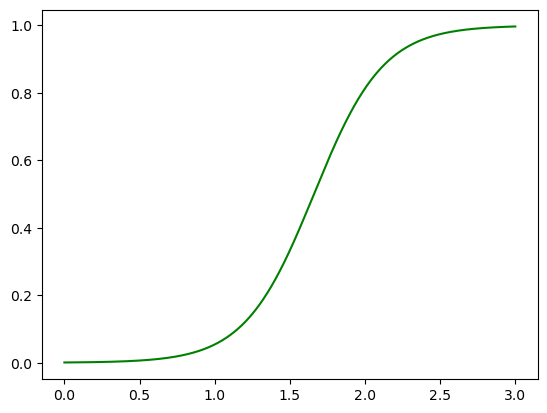

In [13]:
X_new = np.linspace(0,3,1000).reshape(-1,1)
y_proba = log_reg.predict_proba(X_new)
plt.plot(X_new, y_proba[:,1], "g-", label = "Iris-Virginica")

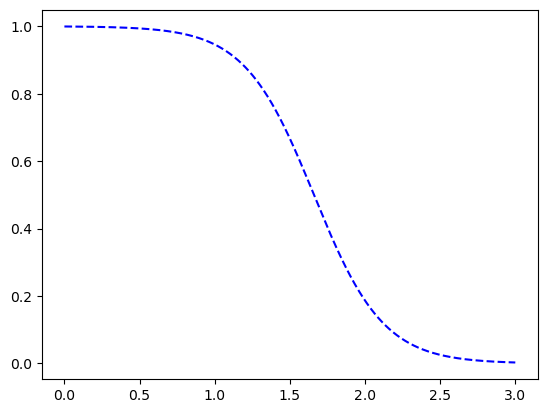

In [14]:
plt.plot(X_new, y_proba[:, 0], "b--", label="Not Iris-Virginica")

In [16]:
log_reg.predict([[1.7], [1.5]])

array([1, 0])

In [17]:
X = iris["data"][:,(2,3)]
y = iris["target"]

In [20]:
softmax_reg = LogisticRegression(multi_class="multinomial", solver = "lbfgs", C = 10)
softmax_reg.fit(X,y) 

/opt/anaconda3/lib/python3.13/site-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(


LogisticRegression(C=10, multi_class='multinomial')

In [21]:
softmax_reg.predict([[5,2]])
softmax_reg.predict_proba([[5,2]])

array([[6.21626372e-07, 5.73689802e-02, 9.42630398e-01]])

In [24]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.svm import LinearSVC

In [25]:
iris = datasets.load_iris()
X = iris["data"][:, (2,3)]
y = (iris["target"]==2).astype(np.int64)

In [28]:
svm_clf = Pipeline([
    ("scalar", StandardScaler()),
    ("Linear_svc", LinearSVC(C = 1, loss = "hinge")),
])

In [29]:
svm_clf.fit(X,y)

Pipeline(steps=[('scalar', StandardScaler()),
                ('Linear_svc', LinearSVC(C=1, loss='hinge'))])

In [30]:
svm_clf.predict([[5.5, 1.7]])

array([1])

In [31]:
from sklearn.datasets import make_moons
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import PolynomialFeatures

In [32]:
polynomial_svm_clf = Pipeline([
    ("poly_features", PolynomialFeatures(degree = 3)),
    ("Scaler", StandardScaler()),
    ("SVM_clf", LinearSVC(C = 10, loss = "hinge"))
])

In [33]:
polynomial_svm_clf.fit(X,y)

Pipeline(steps=[('poly_features', PolynomialFeatures(degree=3)),
                ('Scaler', StandardScaler()),
                ('SVM_clf', LinearSVC(C=10, loss='hinge'))])

In [34]:
from sklearn.svm import SVC
poly_kernel_svm_clf = Pipeline([
("scaler", StandardScaler()),
("svm_clf", SVC(kernel="poly", degree=3, coef0=1, C=5))
])
poly_kernel_svm_clf.fit(X, y)


Pipeline(steps=[('scaler', StandardScaler()),
                ('svm_clf', SVC(C=5, coef0=1, kernel='poly'))])